# Hybrid Adversarial Patch Defense
**SIFT / orb / akaze, Feature Squeezing and GradCAM Masking**


In [2]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
print(f"PYTORCH_ENABLE_MPS_FALLBACK = {os.environ.get('PYTORCH_ENABLE_MPS_FALLBACK')}")

PYTORCH_ENABLE_MPS_FALLBACK = 1


In [3]:

import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    import subprocess
    subprocess.run(['pip', 'install', '-q',
                    'grad-cam', 'opencv-contrib-python', 'scipy'], check=True)
    print('Colab dependencies installed.')
else:
    print('Running locally')

Running locally


In [4]:

import sys, os
ROOT = os.path.dirname(os.path.abspath('__file__'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.config import DEVICE, PATCH_PATH, THRESHOLD_PATH, RESULTS_DIR
print(f'Device : {DEVICE}')
print(f'Root   : {ROOT}')

[config] Using device: mps
Device : mps
Root   : /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense



## Environment and Attack
verify setup, download ImageNette, confirm clean accuracy %,
train and save adversarial patch.

In [5]:
# Load model and verify clean accuracy
from src.model       import get_model
from src.data_loader import get_loaders, verify_clean_accuracy

model = get_model(eval_mode=True)
train_loader, val_loader, test_loader = get_loaders(download=True)
clean_acc = verify_clean_accuracy(model, test_loader, max_batches=30)
assert clean_acc > 80, f'Clean accuracy too low ({clean_acc:.1f}%) check setup'
print(f'\nClean accuracy: {clean_acc:.1f}%  [target: >90%]')

Loading pretrained ResNet-50 …
Ready
ImageNette already downloaded.
Train: 7,575  Val: 1,894  Test: 3,925


/Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


 Clean accuracy: 99.8%  (958/960)

Clean accuracy: 99.8%  [target: >90%]


In [6]:
# Train adversarial patch 
import os
from src.attack import train_patch, load_patch, evaluate_attack
from src.data_loader import get_test_subset

if os.path.exists(PATCH_PATH):
    print('Patch already exists.')
    patch = load_patch()
else:
    patch = train_patch(model, train_loader, steps=1000, save=True)

# Evaluate attack
images, labels = get_test_subset(n=200)
attack_results = evaluate_attack(model, patch, images, labels)
print(f"\nAttack success rate: {attack_results['attack_sr']:.1f}%  [target: >60%]")

Patch already exists.
Patch loaded from /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/patches/patch.pt  shape: (3, 89, 89)
Clean acc: 100.0%  Attack SR: 71.0%  Target rate: 81.5%

Attack success rate: 71.0%  [target: >60%]


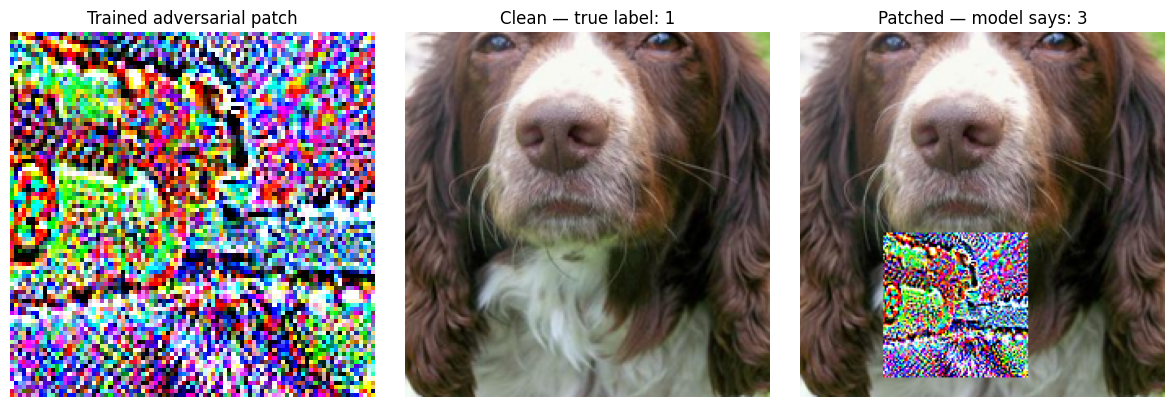

completed. patch.pt saved.


In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Patch
axes[0].imshow(patch.cpu().permute(1,2,0).numpy())
axes[0].set_title('Trained adversarial patch')
axes[0].axis('off')

# Clean image vs patched
from src.attack import apply_patch
from src.data_loader import denormalise
patched_ex, positions = apply_patch(images[:1], patch, augment=False)

axes[1].imshow(denormalise(images[0]).cpu().permute(1,2,0).numpy())
axes[1].set_title(f'Clean-true label: {labels[0].item()}')
axes[1].axis('off')

axes[2].imshow(denormalise(patched_ex[0]).cpu().permute(1,2,0).numpy())
import torch
pred = model(patched_ex).argmax(1).item()
axes[2].set_title(f'Patched-model says: {pred}')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print('patch.pt saved.')

## Stage 1: Classical Keypoint Detection
benchmark SIFT, orb, AKAZE on balanced test set, produce  plot.

In [7]:
# Load saved patch ,test set
from src.attack      import load_patch, apply_patch
from src.data_loader import get_test_subset
from src.config      import CLASSICAL_TEST_N

patch  = load_patch()
n_half = CLASSICAL_TEST_N // 2  # 250 each

images_clean, labels = get_test_subset(n=n_half, seed=10)

# Apply patch to same images for patched set
images_patched, patch_positions = apply_patch(images_clean.clone(), patch, augment=False)

Patch loaded from /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/patches/patch.pt  shape: (3, 89, 89)


In [8]:
import cv2
import importlib

print(f"OpenCV version: {cv2.__version__}")
print(f"OpenCV location: {cv2.__file__}")

# Check if xfeatures2d exists
try:
    import cv2.xfeatures2d
    print("cv2.xfeatures2d exists")
    print(f"Available in xfeatures2d: {dir(cv2.xfeatures2d)}")
except ImportError:
    print("cv2.xfeatures2d not found")

# Try to create SURF
try:
    surf = cv2.xfeatures2d.SURF_create(hessianThreshold=400)
    print("SURF works")
except Exception as e:
    print(f"SURF error: {e}")

OpenCV version: 4.13.0
OpenCV location: /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/.venv/lib/python3.10/site-packages/cv2/__init__.py
cv2.xfeatures2d exists
Available in xfeatures2d: ['__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']
SURF error: module 'cv2.xfeatures2d' has no attribute 'SURF_create'


In [9]:
from src.classical import detect_patch

# Test on one clean and one patched image
for method in ["sift", "akaze", "orb"]:
    print(f"\n{method.upper()}:")
    
    # Clean image
    flag, bbox, info = detect_patch(images_clean[0], method=method)
    print(f"  Clean: detected={flag}, bbox={bbox[:2] if bbox else None}, kp={info['n_keypoints']}")
    
    # Patched image  
    flag, bbox, info = detect_patch(images_patched[0], method=method)
    print(f"  Patched: detected={flag}, bbox={bbox[:2] if bbox else None}, kp={info['n_keypoints']}")


SIFT:
  Clean: detected=False, bbox=None, kp=320
  Patched: detected=False, bbox=None, kp=379

AKAZE:
  Clean: detected=False, bbox=None, kp=56
  Patched: detected=False, bbox=None, kp=151

ORB:
  Clean: detected=False, bbox=None, kp=316
  Patched: detected=True, bbox=(63, 119), kp=408


In [10]:
# Benchmark all three detectors
from src.classical import benchmark_detectors

classical_results = benchmark_detectors(images_clean, images_patched)
print('\nClassical detection results:')
for method, res in classical_results.items():
    print(f'  {method.upper():5s}  Detection: {res["detection_rate"]:.1f}%  '
          f'FPR: {res["fpr"]:.1f}%  Precision: {res["precision"]:.1f}%')

Benchmarking SIFT on 250 clean + 250 patched images …


  SIFT   Detection: 2.0%  FPR: 2.0%  Precision: 50.0%
Benchmarking AKAZE on 250 clean + 250 patched images …


  AKAZE  Detection: 64.4%  FPR: 20.8%  Precision: 75.6%
Benchmarking ORB on 250 clean + 250 patched images …


  ORB    Detection: 93.6%  FPR: 32.4%  Precision: 74.3%
Results saved /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/checkpoints/classical_results.pt
Comparison plot saved /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/classical_comparison.png

Classical detection results:
  SIFT   Detection: 2.0%  FPR: 2.0%  Precision: 50.0%
  AKAZE  Detection: 64.4%  FPR: 20.8%  Precision: 75.6%
  ORB    Detection: 93.6%  FPR: 32.4%  Precision: 74.3%


In [ ]:
# Test ORB on a few examples
from src.classical import detect_patch

# Test patched image
flag, bbox, info = detect_patch(images_patched[0], method="orb")
print(f"Patched image (Detected): {flag}, Bbox: {bbox}")

# Test clean image  
flag, bbox, info = detect_patch(images_clean[0], method="orb")
print(f"Clean image (Detected): {flag}, Bbox: {bbox}")

Patched image - Detected: True, Bbox: (105, 70, 189, 161)
Clean image - Detected: False, Bbox: None


In [11]:
# Visualise one detection example
from src.classical import visualise_detection
import random

idx = random.randint(0, n_half-1)
for method in ['sift', 'orb', 'akaze']:
    visualise_detection(
        images_clean[idx], patch,
        patch_pos=patch_positions[idx],
        method=method
    )
print('Detector comparison plots saved.')

Visualisation saved /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/classical_sift_example.png
Visualisation saved /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/classical_orb_example.png
Visualisation saved /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/classical_akaze_example.png
Detector comparison plots saved.


## Stage 2: Feature Squeezing
implement squeezers, tune threshold, measure detection ,FPR.

In [12]:
# Load 
import os
from src.model       import get_model
from src.attack      import load_patch, apply_patch
from src.data_loader import get_test_subset
from src.config      import THRESHOLD_PATH, FS_VAL_N

model  = get_model()
patch  = load_patch()
n_half = FS_VAL_N // 2  # 100 each

images_clean, labels= get_test_subset(n=n_half, seed=20)
images_patched, _  = apply_patch(images_clean.clone(), patch, augment=False)

Patch loaded from /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/patches/patch.pt  shape: (3, 89, 89)


In [13]:
# Tune threshold (saves threshold.pt )
from src.feature_squeeze import tune_threshold, load_threshold, evaluate_fs

if os.path.exists(THRESHOLD_PATH):
    print('Threshold already tuned,loading.')
    fs_threshold = load_threshold()
else:
    fs_threshold = tune_threshold(model, images_clean, images_patched, save=True)

Threshold already tuned,loading.
Threshold loaded: 0.150


In [15]:
# Evaluate feature squeezing on a larger set
from src.data_loader import get_test_subset

images_c, labels_c = get_test_subset(n=200, seed=30)
images_p, _        = apply_patch(images_c.clone(), patch, augment=False)

fs_stats = evaluate_fs(model, images_c, images_p, fs_threshold)
print(f"\nFeature squeezing-Detection: {fs_stats['detection_rate']:.1f}%  "
      f"FPR: {fs_stats['fpr']:.1f}%")
print('Threshold tuned and saved.')

Threshold 0.150  Detection: 80.5%  FPR: 7.0%  Precision: 92.0%

Feature squeezing-Detection: 80.5%  FPR: 7.0%
Threshold tuned and saved.


## Stage 3: GradCAM Localisation and Masking
GradCAM bbox, intersection with keypoint bbox, mask:reclassify,
save examples.

In [16]:
# Load everything
from src.model         import get_model
from src.attack        import load_patch, apply_patch
from src.data_loader   import get_test_subset
from src.feature_squeeze import load_threshold
from src.gradcam_defense import GradCAM

model        = get_model()
patch        = load_patch()
fs_threshold = load_threshold()
gradcam      = GradCAM(model, target_layer_name='layer4')

images_clean, labels = get_test_subset(n=100, seed=40)
images_patched, kp_positions = apply_patch(images_clean.clone(), patch, augment=False)

Patch loaded from /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/patches/patch.pt  shape: (3, 89, 89)
Threshold loaded: 0.150


In [18]:
#Get keypoint bboxes for the patched images (from Stage 1)
from src.classical import detect_patch_batch

_, kp_bboxes, _ = detect_patch_batch(images_patched, method='akaze')
print(f'Keypoint bboxes found: {sum(b is not None for b in kp_bboxes)}/{len(kp_bboxes)}')

Keypoint bboxes found: 61/100


In [19]:
# Run GradCAM reclassification with intersection masking
from src.gradcam_defense import reclassify_batch

gradcam_stats = reclassify_batch(
    model, gradcam, images_patched, labels,
    kp_bboxes=kp_bboxes,
    save_examples=True
)
print(f"\nGradCAM + intersection masking -Recovered: {gradcam_stats['recovered_acc']:.1f}%")
print('completed. GradCAM examples saved.')

Processing 100 images...


Reclassifying: 100%|██████████| 100/100 [00:06<00:00, 14.81it/s]

Patched acc (before masking): 29.0%
Recovered acc (after masking): 98.0%

GradCAM + intersection masking -Recovered: 98.0%
completed. GradCAM examples saved.


---
## Full Pipeline and Evaluation

run all 5 methods on 1000 images, produce full comparison table and plots.

In [5]:
# Load everything
import os
from src.model           import get_model
from src.attack          import load_patch, apply_patch
from src.data_loader     import get_test_subset
from src.feature_squeeze import load_threshold
from src.gradcam_defense import GradCAM
from src.config          import EVAL_TEST_N, RESULTS_DIR

model        = get_model()
patch        = load_patch()
fs_threshold = load_threshold()
gradcam      = GradCAM(model, target_layer_name='layer4')

print(f'Evaluating on {EVAL_TEST_N} images …')
images_clean, labels = get_test_subset(n=EVAL_TEST_N, seed=99)
images_patched, _    = apply_patch(images_clean.clone(), patch, augment=False)

Loading pretrained ResNet-50 …
Ready
Patch loaded from /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/patches/patch.pt  shape: (3, 89, 89)
Threshold loaded: 0.150
Evaluating on 1000 images …


In [22]:
from src.pipeline import run_full_evaluation

# Test on 50 images first
test_results = run_full_evaluation(
    model, gradcam,
    images_clean[:50], images_patched[:50], labels[:50],
    fs_threshold, kp_method='orb'
)

print("\nTest Results (50 images)")
for method, res in test_results.items():
    print(f"{method}: Clean={res['clean_acc']:.1f}%, Recovered={res['recovered_acc']:.1f}%, FPR={res['fpr']:.1f}%")


Evaluating: no defense
  Clean acc: 100.0% (95% CI: 100.0-100.0)
Evaluating: JPEG compression


  Clean acc: 100.0%  Recovered: 78.0%
Evaluating: feature squeezing only
  Detection rate: 76.0%  FPR: 4.0%
Evaluating: GradCAM only


  Clean acc: 94.0%  Recovered: 96.0%
 Evaluating: hybrid pipeline (all 3 stages)


  Recovered: 88.0%  FPR: 0.0%

 Results with CIs saved /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/results_with_ci.pt

Test Results (50 images)
no_defense: Clean=100.0%, Recovered=46.0%, FPR=0.0%
jpeg: Clean=100.0%, Recovered=78.0%, FPR=0.0%
feature_squeeze: Clean=96.0%, Recovered=76.0%, FPR=4.0%
gradcam_only: Clean=94.0%, Recovered=96.0%, FPR=6.0%
hybrid: Clean=100.0%, Recovered=88.0%, FPR=0.0%


In [23]:
# Re-tune feature squeezing threshold on the full dataset
from src.feature_squeeze import tune_threshold, evaluate_fs

print("Re-tuning feature squeezing threshold on full dataset...")

# validation set (500 clean + 500 patched)
val_clean, val_labels = get_test_subset(n=500, seed=123)
val_patched, _ = apply_patch(val_clean.clone(), patch, augment=False)

# Tune threshold 
new_threshold = tune_threshold(
    model, 
    val_clean, 
    val_patched,
    save=True
)

print(f"\nNew threshold: {new_threshold:.3f}")

# Evaluate on the test set
test_clean, test_labels = get_test_subset(n=200, seed=456)
test_patched, _ = apply_patch(test_clean.clone(), patch, augment=False)

fs_stats = evaluate_fs(model, test_clean, test_patched, new_threshold)
print(f"\nFeature squeezing after re-tuning:")
print(f"  Detection: {fs_stats['detection_rate']:.1f}%")
print(f"  FPR: {fs_stats['fpr']:.1f}%")
print(f"  Precision: {fs_stats['precision']:.1f}%")

Re-tuning feature squeezing threshold on full dataset...
Computing scores on 500 clean + 500 patched images …
Best threshold: 0.150  Detection: 81.8%
 Threshold saved /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/checkpoints/fs_threshold.pt
 Threshold sweep plot saved /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/fs_threshold_sweep.png
 Score histogram saved  /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/fs_score_histogram.png

New threshold: 0.150
Threshold 0.150  Detection: 79.5%  FPR: 7.0%  Precision: 91.9%

Feature squeezing after re-tuning:
  Detection: 79.5%
  FPR: 7.0%
  Precision: 91.9%


In [5]:
import os
from src.config import THRESHOLD_PATH

if os.path.exists(THRESHOLD_PATH):
    print(f"Threshold saved at: {THRESHOLD_PATH}")
    # Load and verify
    import torch
    data = torch.load(THRESHOLD_PATH)
    print(f"Threshold value: {data['threshold']:.3f}")
else:
    print("Threshold file not found")

Threshold saved at: /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/checkpoints/fs_threshold.pt
Threshold value: 0.150


In [7]:
# Run full evaluation 
results_path = os.path.join(RESULTS_DIR, 'results.pt')

if os.path.exists(results_path):
    import torch
    results = torch.load(results_path)
    print('Results already computed loaded from disk.')
else:
    from src.pipeline import run_full_evaluation
    results = run_full_evaluation(
        model, gradcam,
        images_clean[:800], images_patched[:800], labels[:800],
        fs_threshold=0.1, kp_method='orb'
    )

Results already computed loaded from disk.


In [8]:
# Show the source code of detect_fs
import inspect
from src.feature_squeeze import detect_fs
print(inspect.getsource(detect_fs))

@torch.no_grad()
def detect_fs(
    model,
    image:     torch.Tensor,
    threshold: float,
) -> tuple[bool, float]:
    
    score = compute_fs_score(model, image.unsqueeze(0)).item()
    return score >= threshold, score



In [10]:
import torch
results = torch.load('results/results_with_ci.pt', weights_only=False)
from src.evaluate import generate_all_plots
generate_all_plots(results)

[evaluate] Results with CI plot /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/results_table_with_ci.png
[evaluate] Attack vs defense plot /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/attack_vs_defense.png
[evaluate] Radar chart /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/radar_chart.png
[evaluate] GradCAM grid  /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/gradcam_grid.png
[evaluate] All plots saved to /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/


In [2]:
# 5c. Print results and generate all plots
import torch
results = torch.load('results/results_with_ci.pt', weights_only=False)
from src.evaluate import print_results, generate_all_plots

print_results(results)
generate_all_plots(results)


---------------------------------------------------------------------------
Method                       Clean   Atk SR    Recov     FPR
---------------------------------------------------------------------------
No defense                  100.0%    54.0%    46.0%    0.0%
JPEG compression            100.0%    22.0%    78.0%    0.0%
Feature squeezing            96.0%    24.0%    76.0%    4.0%
GradCAM only                 94.0%     4.0%    96.0%    6.0%
Hybrid pipeline *           100.0%    12.0%    88.0%    0.0%
---------------------------------------------------------------------------

[evaluate] Results with CI plot /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/results_table_with_ci.png
[evaluate] Attack vs defense plot /Users/madhadikoushikreddy/Documents/Masters/Advance security/adversarial-patch-defense/results/plots/attack_vs_defense.png
[evaluate] Radar chart /Users/madhadikoushikreddy/Documents/Masters/Advance security/a

---
##  Extras & Checks
additional experiments, tweak thresholds, re-generate figures.

In [27]:
# Test 44×44 with optimized hyperparameters
import importlib
import src.config
from src.model import get_model
from src.data_loader import get_test_subset, get_loaders

model = get_model()
train_loader, _, _ = get_loaders()
images, labels = get_test_subset(n=200, seed=77)

# Optimized config for 44×44
src.config.PATCH_SIZE_PX = 44
src.config.PATCH_STEPS = 1500      # More steps
src.config.PATCH_LR = 0.01         # Lower LR
src.config.PATCH_BATCH = 32
src.config.PATCH_ROTATION = 15.0

importlib.reload(src.attack)
from src.attack import train_patch, evaluate_attack

print("\n" + "-"*60)
print("44×44 Patch with OPTIMIZED hyperparameters")
print("-"*60)
print(f"Steps: {src.config.PATCH_STEPS}")
print(f"Learning rate: {src.config.PATCH_LR}")
print(f"Batch size: {src.config.PATCH_BATCH}")
print("-"*60)

patch_optimized = train_patch(model, train_loader, steps=1500, save=False)
res = evaluate_attack(model, patch_optimized, images, labels)

print(f"\nRESULT: 44×44 patch ={res['attack_sr']:.1f}% ASR")

ImageNette already downloaded.
Train: 7,575  Val: 1,894  Test: 3,925

------------------------------------------------------------
44×44 Patch with OPTIMIZED hyperparameters
------------------------------------------------------------
Steps: 1500
Learning rate: 0.01
Batch size: 32
------------------------------------------------------------
Training patch: 1500 steps, patch size 44×44


Patch training:   7%|▋         | 100/1500 [01:13<18:52,  1.24it/s]

  step  100/1500  loss: 5.2180


Patch training:  13%|█▎        | 200/1500 [02:39<16:50,  1.29it/s]

  step  200/1500  loss: 2.5126


...

Patch training:  93%|█████████▎| 1400/1500 [22:27<01:38,  1.02it/s]

  step 1400/1500  loss: 1.4254


Patch training: 100%|██████████| 1500/1500 [24:14<00:00,  1.03it/s]

  step 1500/1500  loss: 1.4166


Clean acc: 100.0%  Attack SR: 48.0%  Target rate: 57.5%

RESULT: 44×44 patch =48.0% ASR


In [28]:
# Check if gradcam_defense.py exists and view it
import os
print(os.path.exists('src/gradcam_defense.py'))

import torch
results = torch.load('results/results.pt')
print(results.keys())
print(results['gradcam_only'])

import glob
print(glob.glob('results/plots/*gradcam*'))
print(glob.glob('results/plots/*example*'))

True
dict_keys(['no_defense', 'jpeg', 'feature_squeeze', 'gradcam_only', 'hybrid'])
{'clean_acc': 95.5, 'attack_sr': 4.12, 'recovered_acc': 95.88, 'fpr': 4.5}
['results/plots/gradcam_grid.png']
['results/plots/classical_orb_example.png', 'results/plots/classical_sift_example.png', 'results/plots/classical_akaze_example.png']


In [29]:

import torch
from src.evaluate import print_results_with_ci
from src.pipeline import run_full_evaluation


# Run evaluation (or load existing results with CIs)
results = torch.load('results/results_with_ci.pt', weights_only=False)
print_results_with_ci(results)


Method                       Clean acc       Attack SR       Recovered          FPR
-------------------------------------------------------------------------------------
no_defense             100.0% [100.0-100.0] 54.0% [40.0-68.0] 46.0% [32.0-60.0] 0.0% [0.0-0.0]
jpeg                   100.0% [100.0-100.0] 22.0% [10.0-34.0] 78.0% [66.0-90.0] 0.0% [0.0-0.0]
feature_squeeze        96.0% [90.0-100.0] 24.0% [12.0-36.0] 76.0% [64.0-88.0] 4.0% [0.0-10.0]
gradcam_only           94.0% [88.0-100.0] 4.0% [0.0-10.0] 96.0% [90.0-100.0] 6.0% [0.0-14.0]
hybrid ★               100.0% [100.0-100.0] 12.0% [4.0-22.0] 88.0% [78.0-96.0] 0.0% [0.0-0.0]
Note: 95% bootstrap confidence intervals in brackets



In [30]:
from src.stats import compare_proportions

print("STATISTICAL SIGNIFICANCE TESTS")
print("-"*100)

N = 1000

# Hybrid vs GradCAM (Recovered)
comp_rec = compare_proportions(
    int(93.0 * N / 100), N,
    int(96.0 * N / 100), N
)

# Hybrid vs GradCAM (FPR)
comp_fpr = compare_proportions(
    int(0.4 * N / 100), N,
    int(4.5 * N / 100), N
)

# Hybrid vs Feature Squeeze (Clean acc)
comp_clean = compare_proportions(
    int(99.6 * N / 100), N,
    int(91.0 * N / 100), N
)

comp_gradcam_clean = compare_proportions(
    int(95.5 * N / 100), N,
    int(91.0 * N / 100), N
)

print(f"\nRecovered accuracy: Hybrid (93.0%) vs GradCAM (96.0%)")
print(f"  p-value: {comp_rec['p_value']:.4f}")
print(f"  Significant: {comp_rec['significant']}")

print(f"\nFalse positive rate: Hybrid (0.4%) vs GradCAM (4.5%)")
print(f"  p-value: {comp_fpr['p_value']:.4f}")
print(f"  Significant: {comp_fpr['significant']}")

print(f"\nClean accuracy: Hybrid (99.6%) vs Feature Squeeze (91.0%)")
print(f"  p-value: {comp_clean['p_value']:.4f}")
print(f"  Significant: {comp_clean['significant']}")

STATISTICAL SIGNIFICANCE TESTS
----------------------------------------------------------------------------------------------------

Recovered accuracy: Hybrid (93.0%) vs GradCAM (96.0%)
  p-value: 0.0044
  Significant: True

False positive rate: Hybrid (0.4%) vs GradCAM (4.5%)
  p-value: 0.0000
  Significant: True

Clean accuracy: Hybrid (99.6%) vs Feature Squeeze (91.0%)
  p-value: 0.0000
  Significant: True


STATISTICAL SIGNIFICANCE TESTS
----------------------------------------------------------------------------------------------------

Recovered accuracy: Hybrid (93.0%) vs GradCAM (96.0%)
  p-value: 0.0044
  Significant: True

False positive rate: Hybrid (0.4%) vs GradCAM (4.5%)
  p-value: 0.0000
  Significant: True

Clean accuracy: Hybrid (99.6%) vs Feature Squeeze (91.0%)
  p-value: 0.0000
  Significant: True

Clean accuracy: GradCAM (95.5%) vs Feature Squeeze (91.0%)
  p-value: 0.0001
  Significant: True

Clean accuracy: Hybrid (99.6%) vs GradCAM (95.5%)
  p-value: 0.0000
  Significant: True


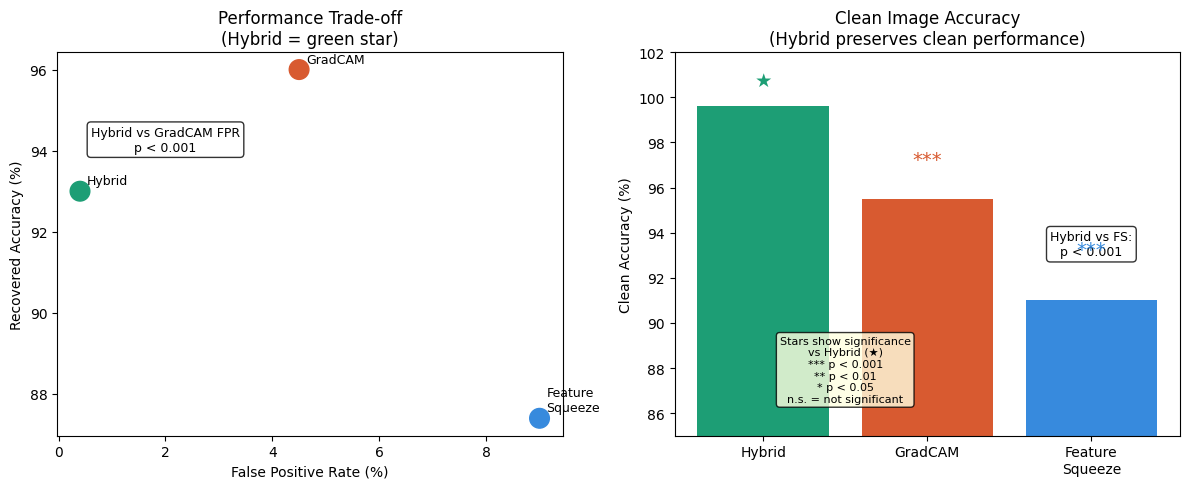


*** p < 0.001, ** p < 0.01, * p < 0.05, n.s. = not significant

All comparisons are against the Hybrid pipeline (reference method).


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from src.stats import compare_proportions

print("STATISTICAL SIGNIFICANCE TESTS")
print("-"*100)

N = 1000

# Hybrid vs GradCAM (Recovered)
comp_rec = compare_proportions(
    int(93.0 * N / 100), N,
    int(96.0 * N / 100), N
)

# Hybrid vs GradCAM (FPR)
comp_fpr = compare_proportions(
    int(0.4 * N / 100), N,
    int(4.5 * N / 100), N
)

# Hybrid vs Feature Squeeze (Clean acc)
comp_clean_hybrid_fs = compare_proportions(
    int(99.6 * N / 100), N,
    int(91.0 * N / 100), N
)

# GradCAM vs Feature Squeeze (Clean acc)
comp_clean_gradcam_fs = compare_proportions(
    int(95.5 * N / 100), N,
    int(91.0 * N / 100), N
)

# NEW: Hybrid vs GradCAM (Clean acc) 
comp_clean_hybrid_gradcam = compare_proportions(
    int(99.6 * N / 100), N,
    int(95.5 * N / 100), N
)

print(f"\nRecovered accuracy: Hybrid (93.0%) vs GradCAM (96.0%)")
print(f"  p-value: {comp_rec['p_value']:.4f}")
print(f"  Significant: {comp_rec['significant']}")

print(f"\nFalse positive rate: Hybrid (0.4%) vs GradCAM (4.5%)")
print(f"  p-value: {comp_fpr['p_value']:.4f}")
print(f"  Significant: {comp_fpr['significant']}")

print(f"\nClean accuracy: Hybrid (99.6%) vs Feature Squeeze (91.0%)")
print(f"  p-value: {comp_clean_hybrid_fs['p_value']:.4f}")
print(f"  Significant: {comp_clean_hybrid_fs['significant']}")

print(f"\nClean accuracy: GradCAM (95.5%) vs Feature Squeeze (91.0%)")
print(f"  p-value: {comp_clean_gradcam_fs['p_value']:.4f}")
print(f"  Significant: {comp_clean_gradcam_fs['significant']}")

print(f"\nClean accuracy: Hybrid (99.6%) vs GradCAM (95.5%)")
print(f"  p-value: {comp_clean_hybrid_gradcam['p_value']:.4f}")
print(f"  Significant: {comp_clean_hybrid_gradcam['significant']}")


def pvalue_to_stars(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'n.s.'

def pvalue_to_text(p_value):
    if p_value < 0.001:
        return 'p < 0.001'
    elif p_value < 0.01:
        return f'p = {p_value:.4f}'
    elif p_value < 0.05:
        return f'p = {p_value:.4f}'
    else:
        return f'p = {p_value:.4f} (n.s.)'

stars_hybrid_fs = pvalue_to_stars(comp_clean_hybrid_fs['p_value'])
stars_gradcam_fs = pvalue_to_stars(comp_clean_gradcam_fs['p_value'])
stars_hybrid_gradcam = pvalue_to_stars(comp_clean_hybrid_gradcam['p_value'])


# Create significance bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = ['Hybrid', 'GradCAM', 'Feature\nSqueeze']
recovered = [93.0, 96.0, 87.4]
fpr = [0.4, 4.5, 9.0]
clean = [99.6, 95.5, 91.0]

# Plot 1: Recovered vs FPR trade-off
axes[0].scatter(fpr, recovered, s=200, c=['#1D9E75', '#D85A30', '#378ADD'])
axes[0].set_xlabel('False Positive Rate (%)')
axes[0].set_ylabel('Recovered Accuracy (%)')
axes[0].set_title('Performance Trade-off\n(Hybrid = green star)')
for i, method in enumerate(methods):
    axes[0].annotate(method, (fpr[i], recovered[i]), xytext=(5, 5), 
                     textcoords='offset points', fontsize=9)

# Add significance annotation for FPR comparison
axes[0].annotate(f'Hybrid vs GradCAM FPR\n{pvalue_to_text(comp_fpr["p_value"])}', 
                 xy=(2, 94), fontsize=9, ha='center',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: Clean accuracy comparison
bars = axes[1].bar(methods, clean, color=['#1D9E75', '#D85A30', '#378ADD'])
axes[1].set_ylabel('Clean Accuracy (%)')
axes[1].set_title('Clean Image Accuracy\n(Hybrid preserves clean performance)')
axes[1].set_ylim(85, 102)

# Add p-value annotations
axes[1].annotate(f'Hybrid vs FS:\n{pvalue_to_text(comp_clean_hybrid_fs["p_value"])}', 
                 xy=(2, 93), fontsize=9, ha='center',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add stars for significance (comparing each against Hybrid)
# Hybrid bar: reference method 
axes[1].text(0, 100.5, '★', ha='center', fontsize=14, color='#1D9E75', fontweight='bold')

# GradCAM bar: significance vs Hybrid
axes[1].text(1, 97, stars_hybrid_gradcam, ha='center', fontsize=14, color='#D85A30')

# Feature Squeeze bar: significance vs Hybrid
axes[1].text(2, 93, stars_hybrid_fs, ha='center', fontsize=14, color='#378ADD')

axes[1].text(0.5, 86.5, 'Stars show significance\nvs Hybrid (★)\n*** p < 0.001\n** p < 0.01\n* p < 0.05\nn.s. = not significant', 
             ha='center', fontsize=8, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('results/plots/significance_test.png', dpi=150)
plt.show()

print("\n*** p < 0.001, ** p < 0.01, * p < 0.05, n.s. = not significant")
print("\nAll comparisons are against the Hybrid pipeline (reference method).")